In [1]:
txt = '''
Fragen zur Datensatz auswahl bzw. erweitung:


1. Struktur der Datensätze verstehen
# Dataset Structure – CICEV2023

- **CSs per simulation run:** 53 (see `cs_installation.csv`), but only 3 CSs have recorded perf stat data
- **Features:** 3 of 8 available perf stat metrics: `branch`, `cycles`, `instructions`
- **Sampling:** relative timestamps (seconds since start), uniform interval of ~0.10s per data point
- **Label distribution:** ~1/3 attack (~274 points, ~28s), ~2/3 normal (~484 points, ~52s) per CS; ~600–800 total data points per CS

---

# Dataset Structure – CICEVSE2024 (EVSE-B)

## Power Consumption
- **Features:** `shunt_voltage`, `bus_voltage_V`, `current_mA`, `power_mW`, `State`, `Attack`, `Attack-Group`, `Label`, `interface`
- **Sampling:** absolute timestamps (minute-level granularity), avg. interval ~3.4s, total duration ~6 days
- **Label distribution:** 88% attack, 12% benign (115,298 total data points)

## HPC & Kernel Events
- **Features:** 900+ HPC and kernel event counters (perf stat)
- **Sampling:** relative timestamps (seconds since start), 5s sampling interval, total duration ~97 minutes
- **Label distribution:** 63% attack, 37% benign (8,474 total data points)



2. Vergleich mit deinem ReSiLENT-System
Welche Features aus CICEV2023 überschneiden sich mit deinen ReSiLENT-Features?
ja branch, cycles, instructions gibt im ReSiLENT auch

Welche Features aus CICEVSE2024 überschneiden sich?
ja vor allem power-comsumption gibt es 1 zu 1 und HCP und Kernel überschneiden sich auch über 95%


3. Anforderungen deines Aggregationsansatzes klären
Wie viele Knoten brauchst du mindestens, damit dein Aggregationsansatz überhaupt sinnvoll evaluierbar ist?
10 oder mehr wäre gut

Muss jeder Knoten dieselben Features liefern?
ja jeder Knoten muss dieselben Features liefern!

Reicht es, wenn die Knoten zeitlich synchronisiert sind?
die Knoten müssen zeitlich synchronisiert sein sonst macht die kontexinformation keinen Sinn

4. Aufwandsabschätzung
CICEV2023: Sind die Daten direkt nutzbar oder müssen sie erst aufbereitet werden?
ist alles in .json file, aber an sich gut aufbereitet

CICEVSE2024: Was genau müsstest du synthetisch erzeugen – nur mehr Knoten, oder auch mehr Angriffsvarianten?
ist alles in .csv files, aber an sich gut aufbereitet
'''

print(txt)


Fragen zur Datensatz auswahl bzw. erweitung:


1. Struktur der Datensätze verstehen
# Dataset Structure – CICEV2023

- **CSs per simulation run:** 53 (see `cs_installation.csv`), but only 3 CSs have recorded perf stat data
- **Features:** 3 of 8 available perf stat metrics: `branch`, `cycles`, `instructions`
- **Sampling:** relative timestamps (seconds since start), uniform interval of ~0.10s per data point
- **Label distribution:** ~1/3 attack (~274 points, ~28s), ~2/3 normal (~484 points, ~52s) per CS; ~600–800 total data points per CS

---

# Dataset Structure – CICEVSE2024 (EVSE-B)

## Power Consumption
- **Features:** `shunt_voltage`, `bus_voltage_V`, `current_mA`, `power_mW`, `State`, `Attack`, `Attack-Group`, `Label`, `interface`
- **Sampling:** absolute timestamps (minute-level granularity), avg. interval ~3.4s, total duration ~6 days
- **Label distribution:** 88% attack, 12% benign (115,298 total data points)

## HPC & Kernel Events
- **Features:** 900+ HPC and kernel event c

In [2]:
import pandas as pd

# Load with low_memory=False to avoid mixed type warning
df_hpc = pd.read_csv(
    '../datasets/CICEVSE2024/Host Events/EVSE-B-HPC-Kernel-Events-Combined.csv',
    low_memory=False
)
df_power = pd.read_csv('../datasets/CICEVSE2024/Power Consumption/EVSE-B-PowerCombined.csv')

# Structural overview for both
for name, df in [('HPC-Kernel-Events', df_hpc), ('Power-Consumption', df_power)]:
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Missing values:", df.isnull().sum().sum())
    print()

=== HPC-Kernel-Events ===
Shape: (8474, 915)
Columns: ['time', 'alarmtimer_alarmtimer_cancel', 'alarmtimer_alarmtimer_fired', 'alarmtimer_alarmtimer_start', 'alarmtimer_alarmtimer_suspend', 'alignment-faults', 'ase_spec', 'block_block_bio_backmerge', 'block_block_bio_bounce', 'block_block_bio_complete', 'block_block_bio_frontmerge', 'block_block_bio_queue', 'block_block_bio_remap', 'block_block_dirty_buffer', 'block_block_getrq', 'block_block_plug', 'block_block_rq_complete', 'block_block_rq_insert', 'block_block_rq_issue', 'block_block_rq_merge', 'block_block_rq_remap', 'block_block_rq_requeue', 'block_block_split', 'block_block_touch_buffer', 'block_block_unplug', 'bpf-output', 'br_immed_spec', 'br_indirect_spec', 'br_mis_pred', 'br_pred', 'br_return_spec', 'branch-load-misses', 'branch-loads', 'branch-misses', 'bus_access', 'bus_access_normal', 'bus_access_not_shared', 'bus_access_periph', 'bus_access_rd', 'bus_access_shared', 'bus_access_wr', 'bus_cycles', 'bus-cycles', 'cache-miss

Missing values: 0



In [3]:
# Label distribution for both datasets
for name, df in [('HPC-Kernel-Events', df_hpc), ('Power-Consumption', df_power)]:
    print(f"=== {name} ===")
    if 'Label' in df.columns:
        print(df['Label'].value_counts())
        print(f"Total: {len(df)}")
    else:
        print("No 'Label' column found, available columns:", df.columns.tolist())
    print()

=== HPC-Kernel-Events ===
Label
attack                         3864
benign                         2302
0                              2302
writeback:writeback_written       1
Name: count, dtype: int64
Total: 8474

=== Power-Consumption ===
Label
attack    100935
benign     14363
Name: count, dtype: int64
Total: 115298



In [4]:
# Check timestamp columns first
for name, df in [('HPC-Kernel-Events', df_hpc), ('Power-Consumption', df_power)]:
    print(f"=== {name} ===")
    time_cols = [col for col in df.columns if 'time' in col.lower() or 'timestamp' in col.lower() or 'date' in col.lower()]
    print("Timestamp columns:", time_cols)
    if time_cols:
        print(df[time_cols[0]].head())
    print()

=== HPC-Kernel-Events ===
Timestamp columns: ['time', 'alarmtimer_alarmtimer_cancel', 'alarmtimer_alarmtimer_fired', 'alarmtimer_alarmtimer_start', 'alarmtimer_alarmtimer_suspend', 'jbd2_jbd2_update_log_tail', 'net_net_dev_xmit_timeout', 'sched_sched_stat_runtime', 'syscalls_sys_enter_adjtimex', 'syscalls_sys_enter_clock_adjtime', 'syscalls_sys_enter_clock_gettime', 'syscalls_sys_enter_clock_settime', 'syscalls_sys_enter_getitimer', 'syscalls_sys_enter_gettimeofday', 'syscalls_sys_enter_mq_timedreceive', 'syscalls_sys_enter_mq_timedsend', 'syscalls_sys_enter_rt_sigtimedwait', 'syscalls_sys_enter_semtimedop', 'syscalls_sys_enter_setitimer', 'syscalls_sys_enter_settimeofday', 'syscalls_sys_enter_timer_create', 'syscalls_sys_enter_timer_delete', 'syscalls_sys_enter_timer_getoverrun', 'syscalls_sys_enter_timer_gettime', 'syscalls_sys_enter_timer_settime', 'syscalls_sys_enter_timerfd_create', 'syscalls_sys_enter_timerfd_gettime', 'syscalls_sys_enter_timerfd_settime', 'syscalls_sys_enter_tim

In [5]:
# HPC: relative seconds as float
df_hpc['time'] = pd.to_numeric(df_hpc['time'], errors='coerce')

print("=== HPC-Kernel-Events ===")
print("Start (s):            ", df_hpc['time'].min())
print("End (s):              ", df_hpc['time'].max())
print("Duration (s):         ", df_hpc['time'].max() - df_hpc['time'].min())
print("Avg sampling interval:", df_hpc['time'].diff().mean(), "s")

# Power: absolute datetime string
df_power['time'] = pd.to_datetime(df_power['time'], format='%m/%d/%Y %H:%M')

print("\n=== Power-Consumption ===")
print("Start:                ", df_power['time'].min())
print("End:                  ", df_power['time'].max())
print("Duration:             ", df_power['time'].max() - df_power['time'].min())
print("Avg sampling interval:", df_power['time'].diff().mean())

=== HPC-Kernel-Events ===
Start (s):             5.0
End (s):               5855.669471
Duration (s):          5850.669471
Avg sampling interval: 0.7217705430990078 s

=== Power-Consumption ===
Start:                 2023-12-24 16:18:00
End:                   2023-12-30 16:20:00
Duration:              6 days 00:02:00
Avg sampling interval: 0 days 00:00:03.411710


In [6]:
txt = '''
## Note: Dataset Extension Required

Both datasets alone are insufficient for evaluating the aggregation approach (requires >10 synchronized CS nodes with identical features):

- **CICEV2023:** only 2–3 CS nodes, only 3 HPC features → too few nodes **and** too few features
- **CICEVSE2024:** sufficient features (900+ HPC + 4 Power), but only 1 CS node → too few nodes

**Planned approach:** Extend CICEVSE2024 synthetically by generating 9+ additional CS nodes
'''

print(txt)


## Note: Dataset Extension Required

Both datasets alone are insufficient for evaluating the aggregation approach (requires >10 synchronized CS nodes with identical features):

- **CICEV2023:** only 2–3 CS nodes, only 3 HPC features → too few nodes **and** too few features
- **CICEVSE2024:** sufficient features (900+ HPC + 4 Power), but only 1 CS node → too few nodes

**Planned approach:** Extend CICEVSE2024 synthetically by generating 9+ additional CS nodes



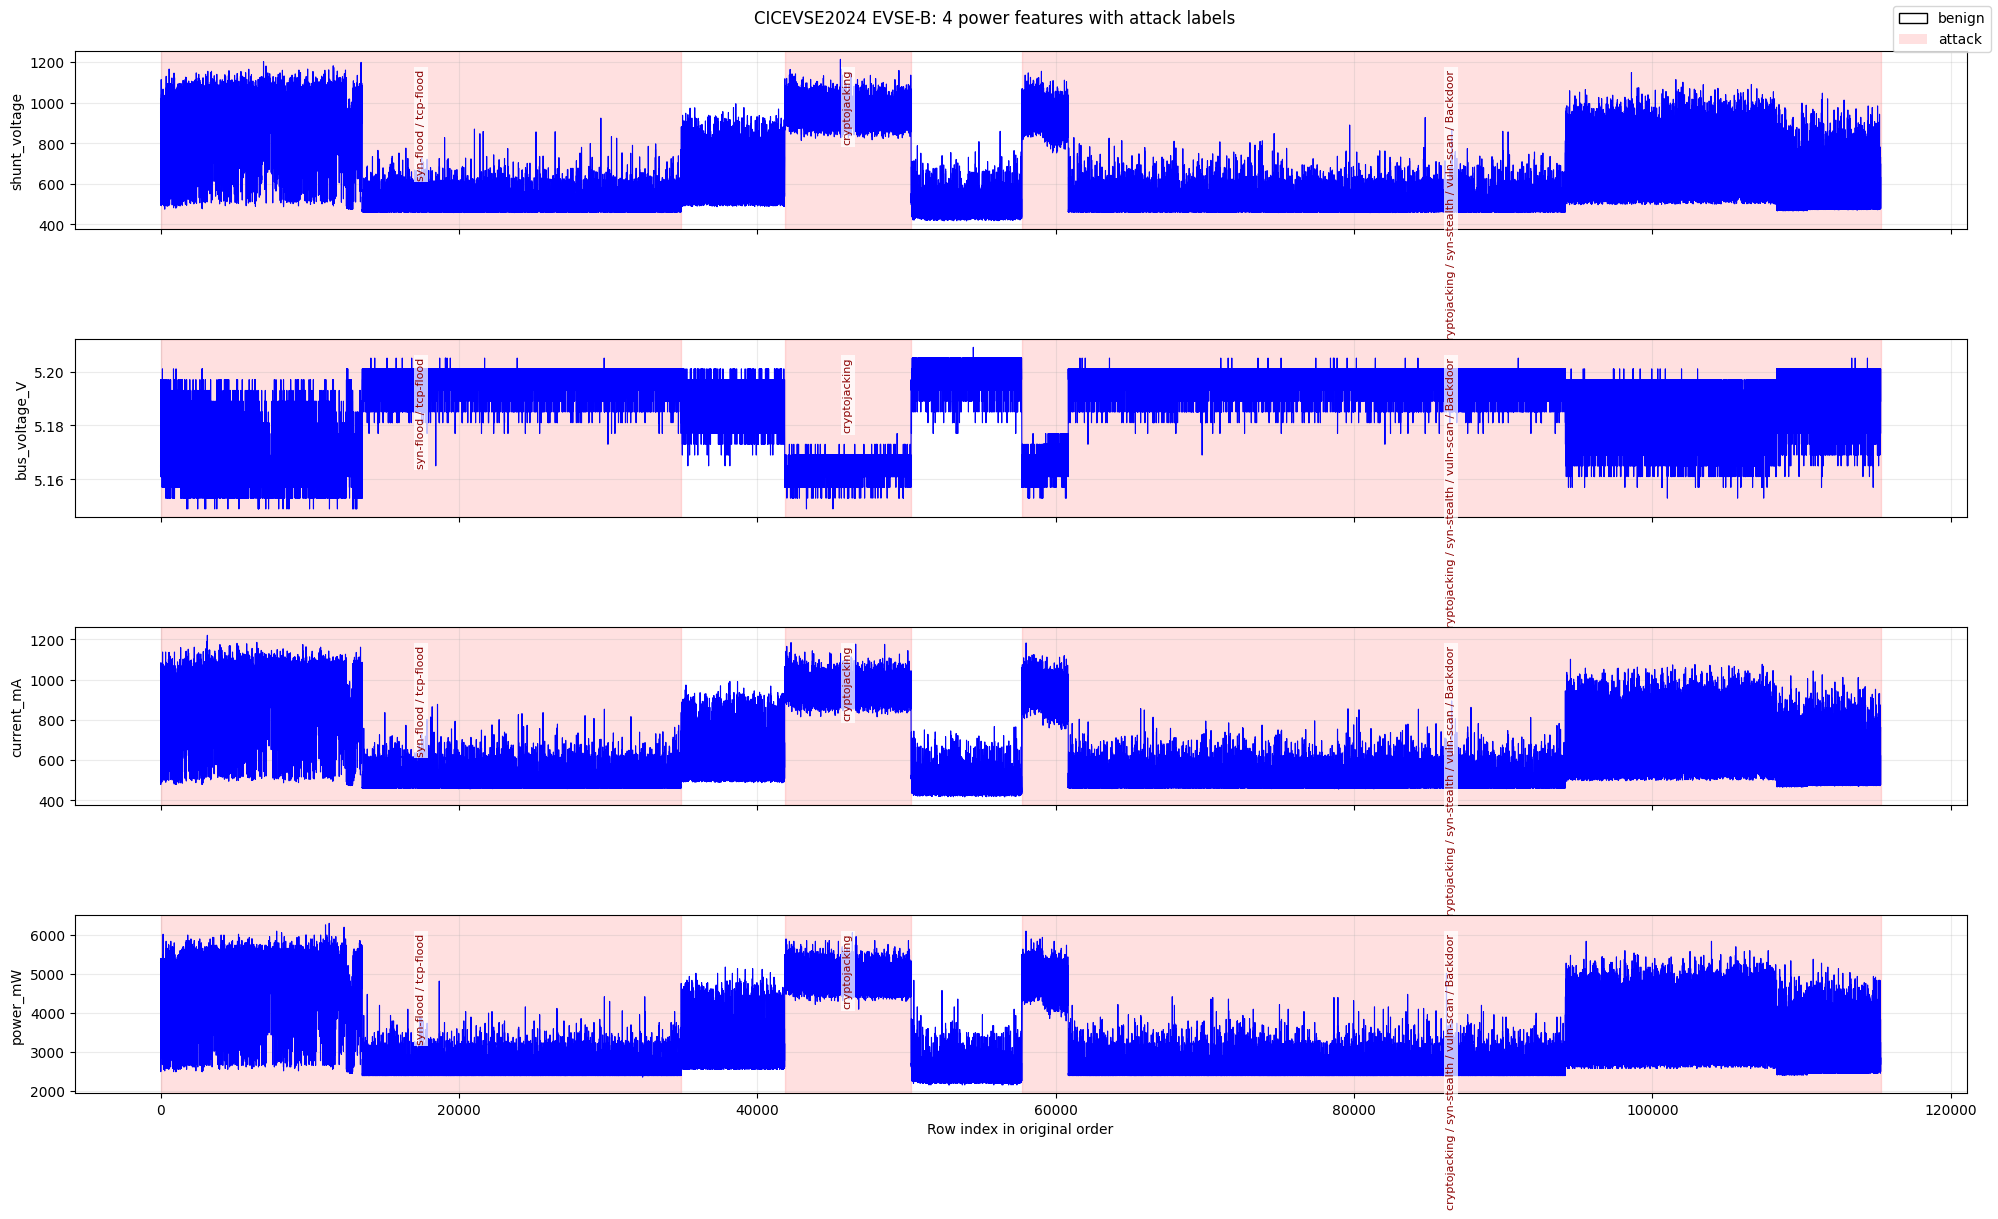

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Copy the already loaded dataframe
df_plot = df_power.copy()

# The 4 power consumption features
features = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]

# Make sure numeric columns are numeric
for col in features:
    df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

# Normalize label columns
df_plot["Label"] = df_plot["Label"].astype(str).str.strip().str.lower()
df_plot["Attack"] = df_plot["Attack"].astype(str).str.strip()

# X-axis: original row order
x = np.arange(len(df_plot))

# Attack mask
attack_mask = df_plot["Label"].eq("attack").to_numpy()

# Build contiguous attack segments and keep their attack labels
segments = []
start = None

for i in range(len(df_plot)):
    if attack_mask[i] and start is None:
        start = i
    elif not attack_mask[i] and start is not None:
        end = i - 1
        attack_names = (
            df_plot.iloc[start:end + 1]["Attack"]
            .replace(["", "nan", "None"], np.nan)
            .dropna()
            .unique()
            .tolist()
        )
        attack_label = " / ".join(map(str, attack_names)) if attack_names else "attack"
        segments.append((start, end, attack_label))
        start = None

# Close last segment if dataset ends with attack
if start is not None:
    end = len(df_plot) - 1
    attack_names = (
        df_plot.iloc[start:end + 1]["Attack"]
        .replace(["", "nan", "None"], np.nan)
        .dropna()
        .unique()
        .tolist()
    )
    attack_label = " / ".join(map(str, attack_names)) if attack_names else "attack"
    segments.append((start, end, attack_label))

# Plot
fig, axes = plt.subplots(len(features), 1, figsize=(20, 12), sharex=True)

for ax, feature in zip(axes, features):
    y = df_plot[feature].to_numpy()

    # White benign background is default figure/axes background
    ax.set_facecolor("white")

    # Plot feature line
    ax.plot(x, y, color="blue", linewidth=0.8, label=feature)

    # Shade attack regions in red and label them
    y_min = np.nanmin(y)
    y_max = np.nanmax(y)
    y_text = y_max - 0.06 * (y_max - y_min)

    for start, end, attack_label in segments:
        ax.axvspan(start, end, color="red", alpha=0.12)

        mid = (start + end) / 2
        ax.text(
            mid,
            y_text,
            attack_label,
            ha="center",
            va="top",
            fontsize=8,
            rotation=90,
            color="darkred",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5)
        )

    ax.set_ylabel(feature)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Row index in original order")
fig.suptitle(
    "CICEVSE2024 EVSE-B: 4 power features with attack labels",
    y=0.995
)

legend_handles = [
    Patch(facecolor="white", edgecolor="black", label="benign"),
    Patch(facecolor="red", alpha=0.12, label="attack")
]
fig.legend(handles=legend_handles, loc="upper right")

plt.tight_layout()
plt.show()

Top 20 hardest attack windows:


,window_id,start_idx,end_idx,window_label,attack_name,attack_fraction,distance_score_l2,distance_score_mean_abs
0,258,15480,15539,attack,tcp-flood,1.0,0.996184,0.215799
1,515,30900,30959,attack,tcp-flood,1.0,1.047374,0.211333
2,1128,67680,67739,attack,syn-stealth,1.0,1.052001,0.211392
3,535,32100,32159,attack,tcp-flood,1.0,1.060871,0.209357
4,1448,86880,86939,attack,vuln-scan,1.0,1.063251,0.217182
5,525,31500,31559,attack,tcp-flood,1.0,1.083204,0.212431
6,572,34320,34379,attack,tcp-flood,1.0,1.087803,0.224636
7,1120,67200,67259,attack,syn-stealth,1.0,1.108709,0.215416
8,1277,76620,76679,attack,vuln-scan,1.0,1.115174,0.218921
9,490,29400,29459,attack,tcp-flood,1.0,1.121238,0.239210


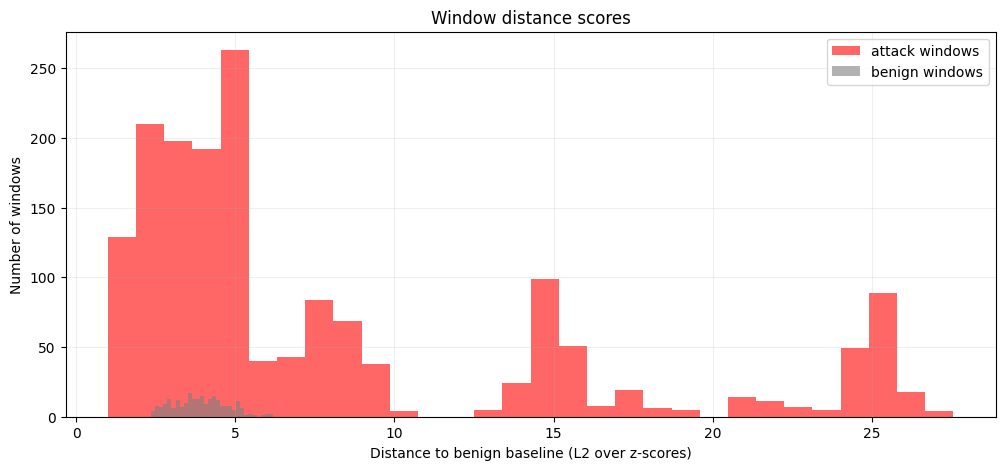

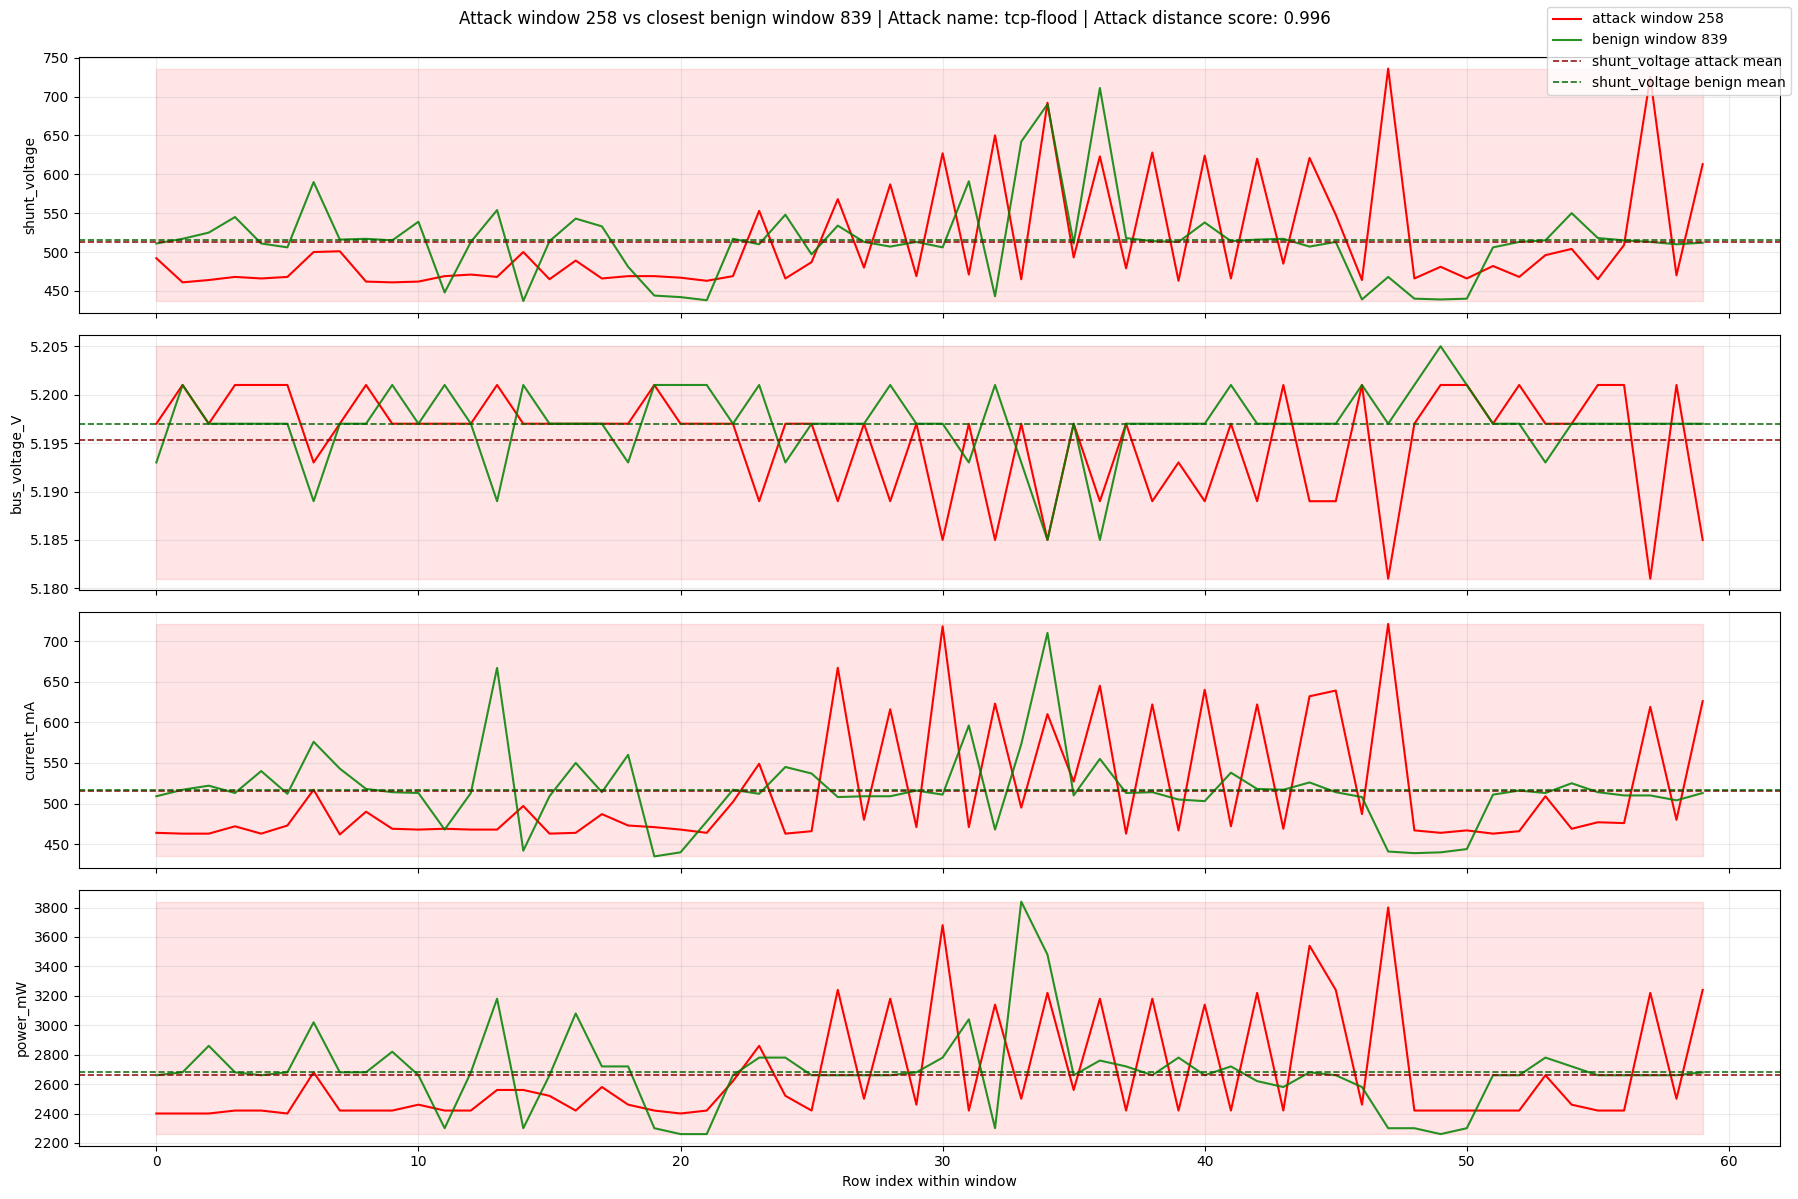

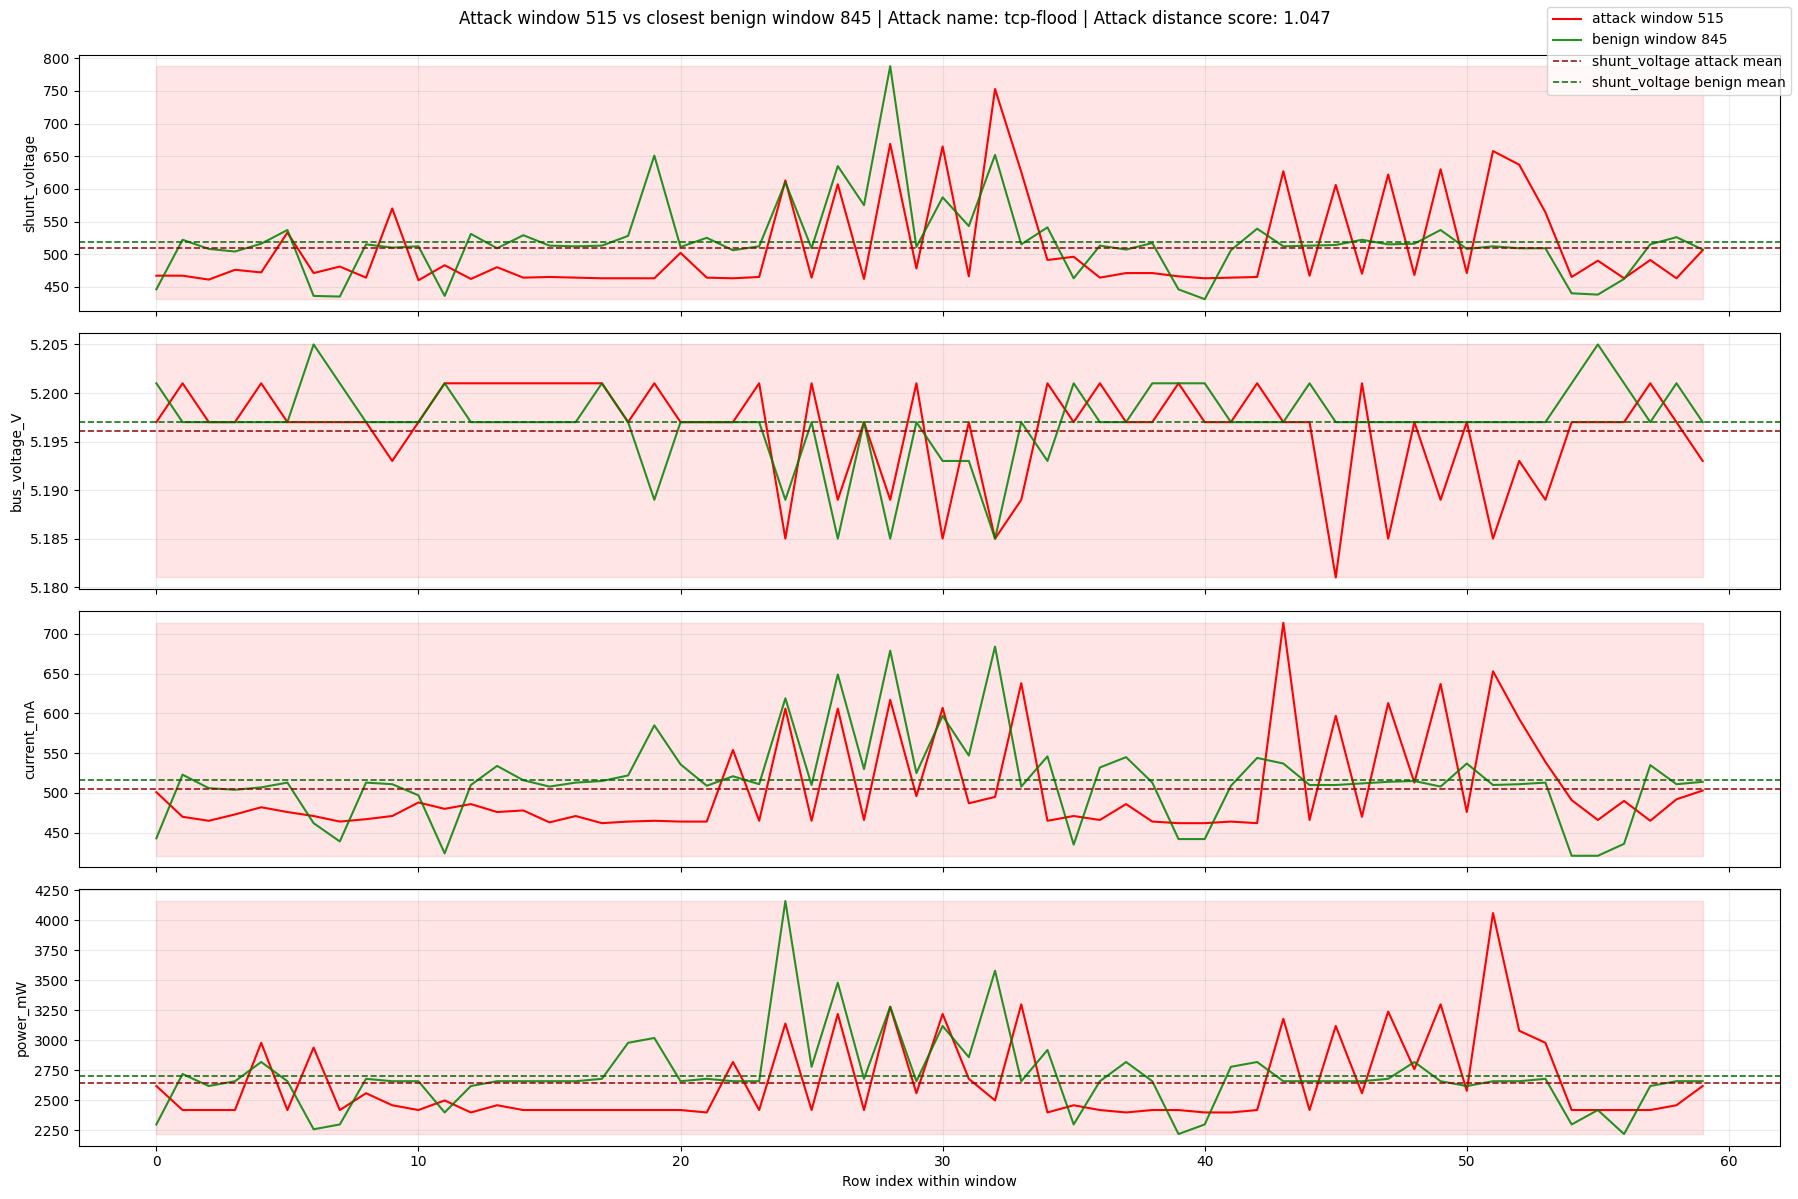

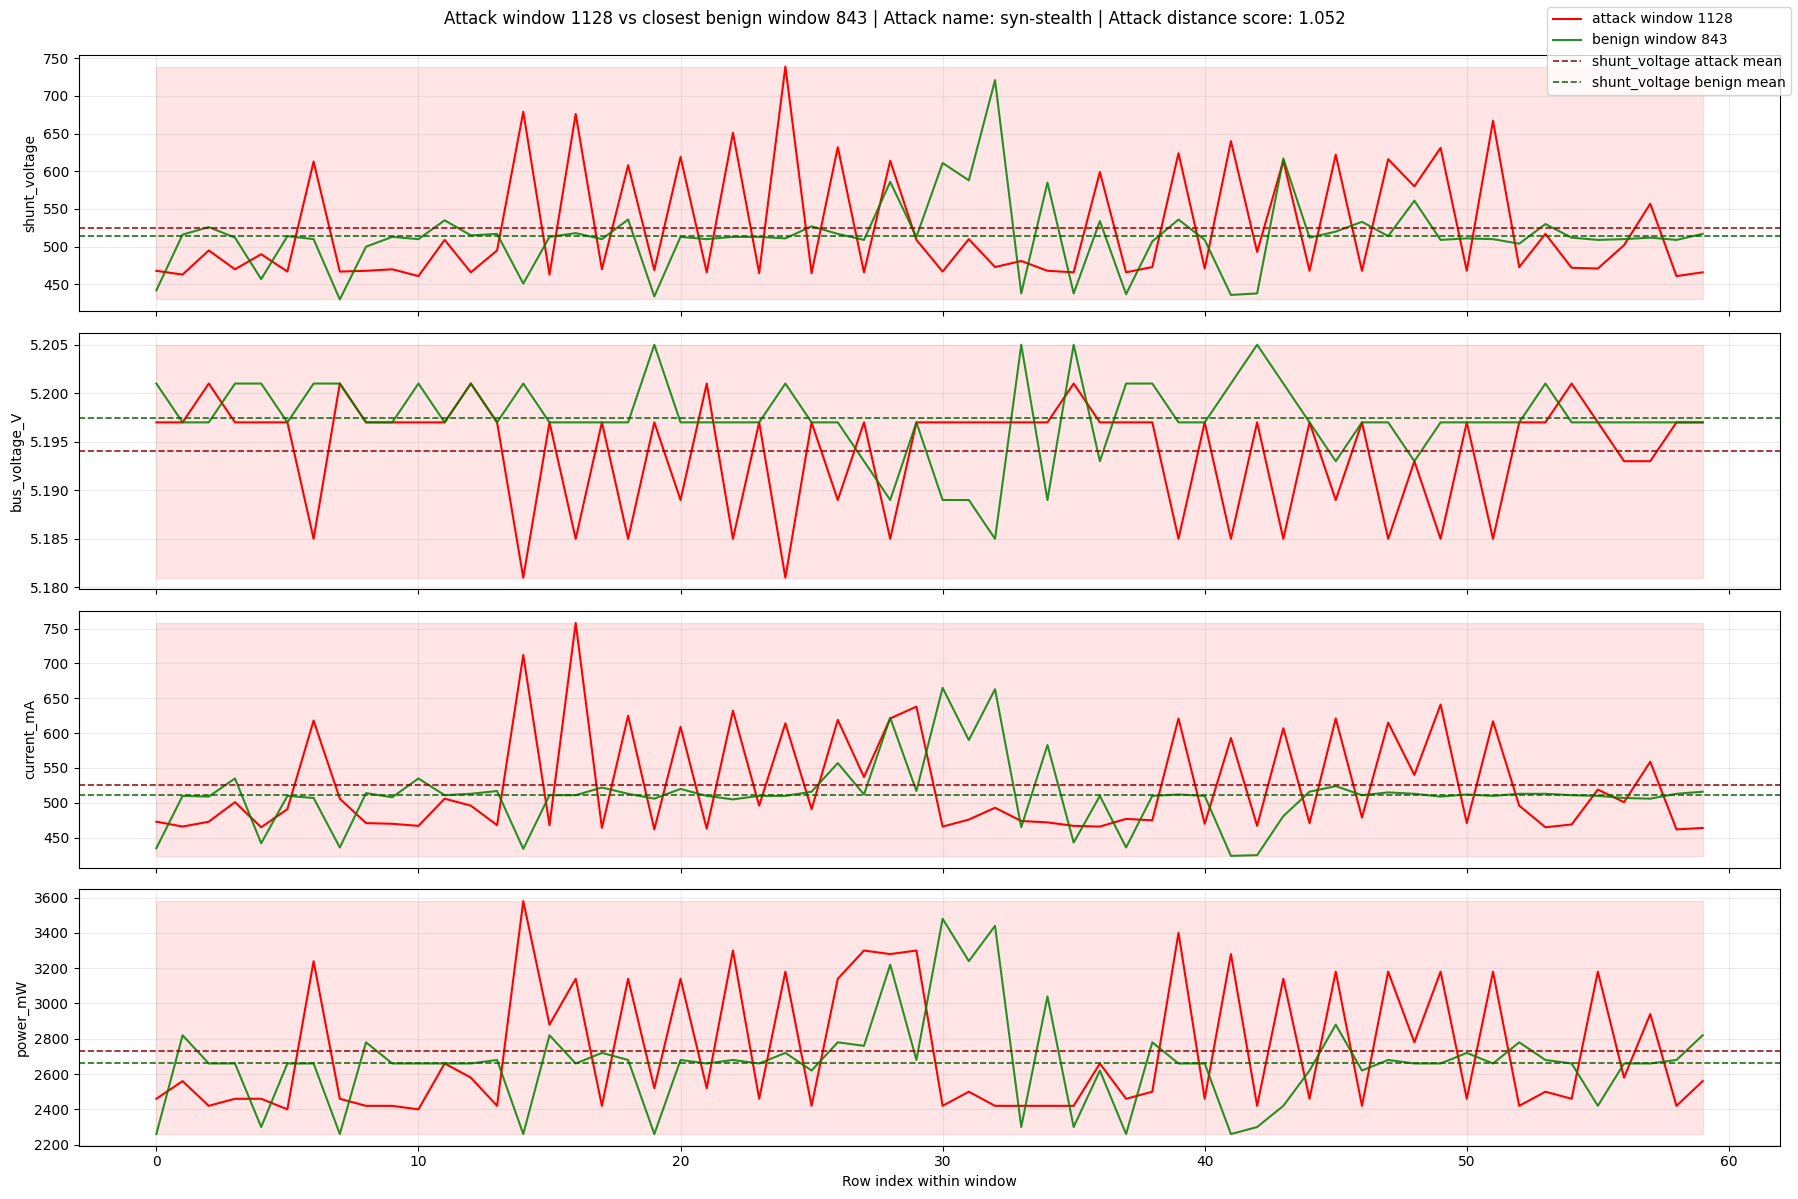

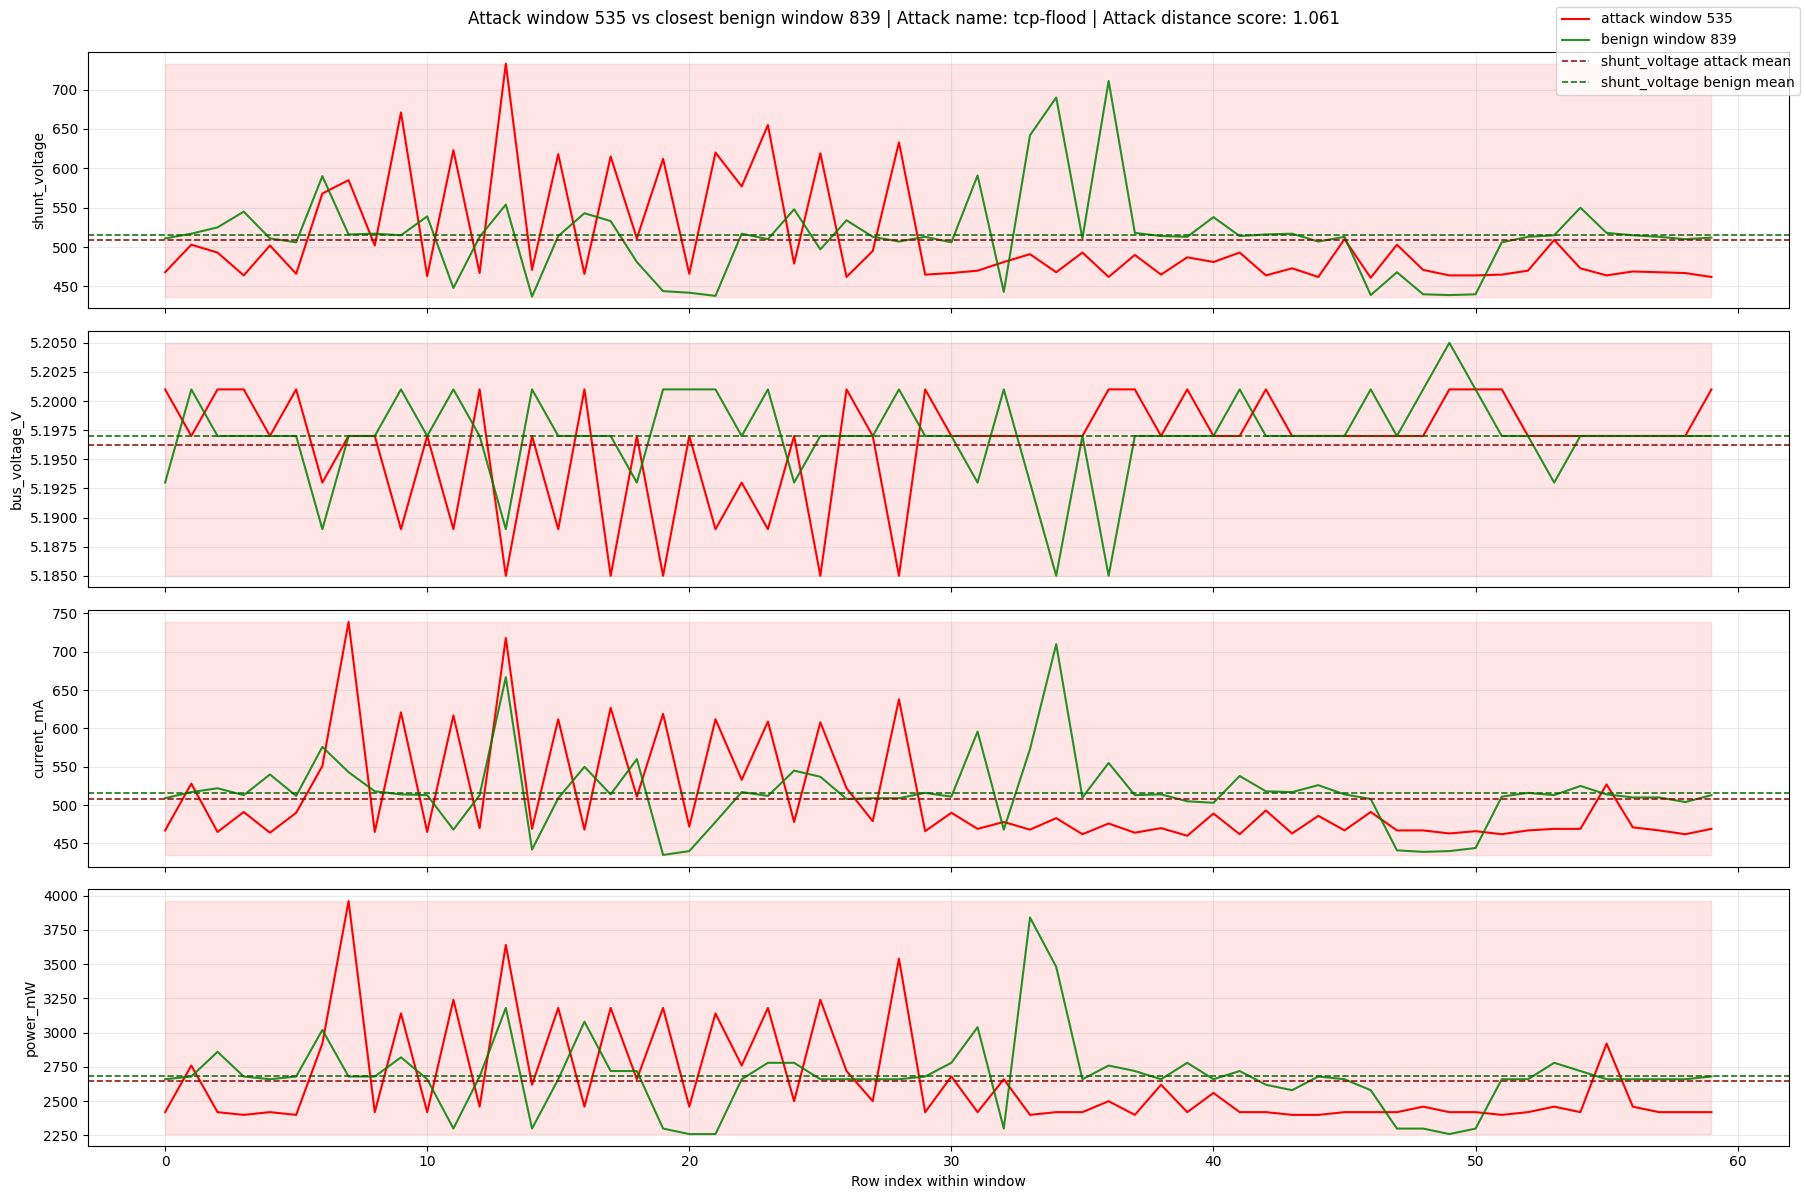

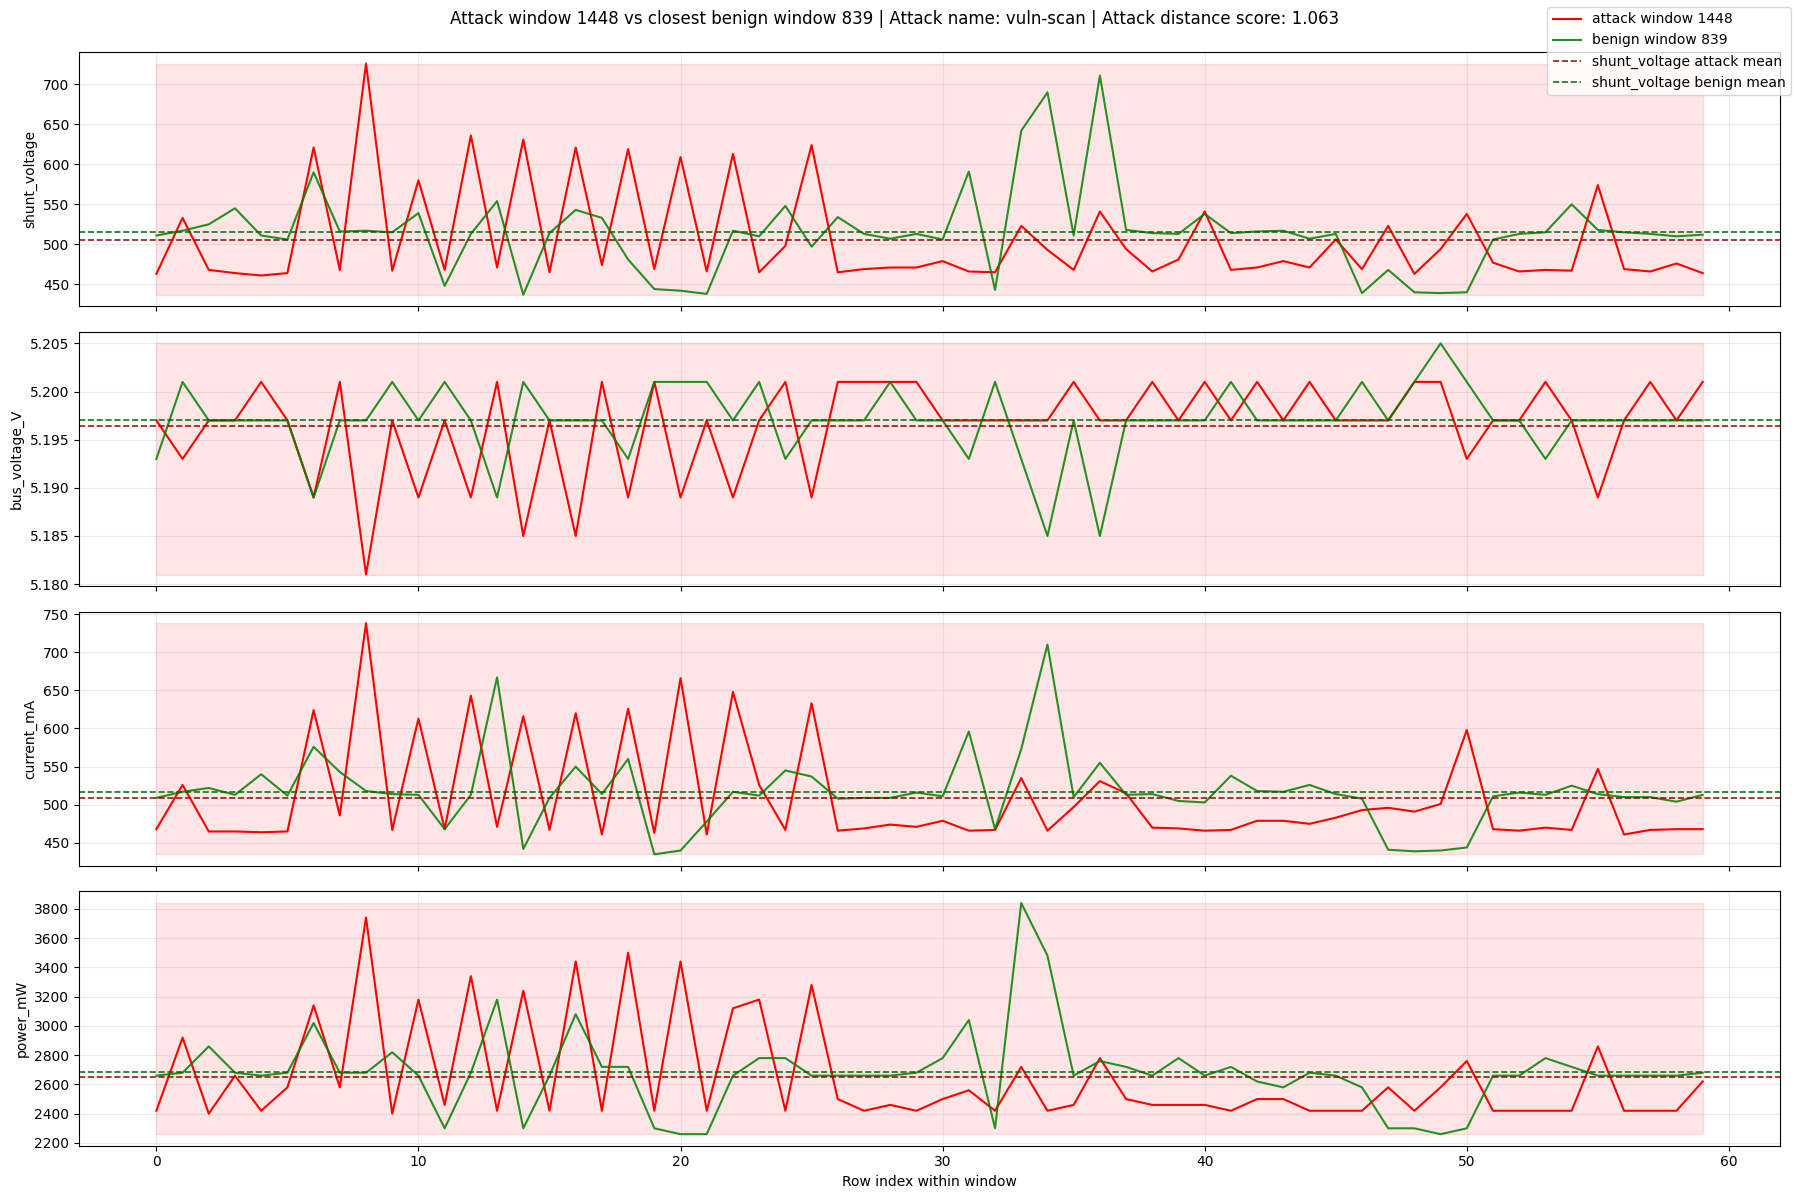

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copy the already loaded dataframe
df = df_power.copy()

# Features to use
features = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]

# Make sure relevant columns exist
required_cols = features + ["Label", "Attack"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Clean types
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Label"] = df["Label"].astype(str).str.strip().str.lower()
df["Attack"] = df["Attack"].astype(str).str.strip()

# Drop rows with missing feature values
df = df.dropna(subset=features).reset_index(drop=True)

# ------------------------------------------------------------
# 1. Split time series into fixed windows
# ------------------------------------------------------------
window_size = 60
df["window_id"] = np.arange(len(df)) // window_size

# ------------------------------------------------------------
# 2. Aggregate each window into summary statistics
# ------------------------------------------------------------
agg_dict = {feature: ["mean", "std", "min", "max"] for feature in features}
window_df = df.groupby("window_id").agg(agg_dict)

# Flatten MultiIndex columns
window_df.columns = [f"{col}_{stat}" for col, stat in window_df.columns]
window_df = window_df.reset_index()

# ------------------------------------------------------------
# 3. Add metadata per window
# ------------------------------------------------------------
meta_rows = []
for window_id, g in df.groupby("window_id"):
    attack_fraction = (g["Label"] == "attack").mean()
    window_label = "attack" if attack_fraction > 0 else "benign"

    attack_names = (
        g.loc[g["Label"] == "attack", "Attack"]
        .replace("", np.nan)
        .dropna()
        .unique()
        .tolist()
    )
    attack_name = " / ".join(attack_names) if attack_names else "benign"

    meta_rows.append({
        "window_id": window_id,
        "start_idx": int(g.index.min()),
        "end_idx": int(g.index.max()),
        "window_label": window_label,
        "attack_name": attack_name,
        "attack_fraction": attack_fraction
    })

meta_df = pd.DataFrame(meta_rows)
window_df = window_df.merge(meta_df, on="window_id", how="left")

# ------------------------------------------------------------
# 4. Build benign baseline from fully benign windows
# ------------------------------------------------------------
feature_summary_cols = [
    c for c in window_df.columns
    if any(c.startswith(f"{f}_") for f in features)
]

baseline_windows = window_df[window_df["attack_fraction"] == 0].copy()

if baseline_windows.empty:
    raise ValueError("No fully benign windows found. Try a smaller window_size.")

benign_mean = baseline_windows[feature_summary_cols].mean()
benign_std = baseline_windows[feature_summary_cols].std(ddof=0).replace(0, 1e-8)

# ------------------------------------------------------------
# 5. Compute z-score distance for each window
# ------------------------------------------------------------
z_scores = (window_df[feature_summary_cols] - benign_mean) / benign_std

window_df["distance_score_l2"] = np.sqrt((z_scores ** 2).sum(axis=1))
window_df["distance_score_mean_abs"] = z_scores.abs().mean(axis=1)

# IMPORTANT:
# Recreate these AFTER the distance columns exist
benign_windows = window_df[window_df["attack_fraction"] == 0].copy()
attack_windows = window_df[window_df["attack_fraction"] > 0].copy()

# Hardest attack windows = smallest distance to benign baseline
attack_windows = attack_windows.sort_values("distance_score_l2", ascending=True).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Show ranked hardest attack windows
# ------------------------------------------------------------
result_cols = [
    "window_id",
    "start_idx",
    "end_idx",
    "window_label",
    "attack_name",
    "attack_fraction",
    "distance_score_l2",
    "distance_score_mean_abs"
]

print("Top 20 hardest attack windows:")
display(attack_windows[result_cols].head(20))

# ------------------------------------------------------------
# 7. Plot histogram of distance scores
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.hist(
    attack_windows["distance_score_l2"],
    bins=30,
    color="red",
    alpha=0.6,
    label="attack windows"
)
plt.hist(
    benign_windows["distance_score_l2"],
    bins=30,
    color="gray",
    alpha=0.6,
    label="benign windows"
)
plt.xlabel("Distance to benign baseline (L2 over z-scores)")
plt.ylabel("Number of windows")
plt.title("Window distance scores")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Recreate subsets safely
benign_windows = window_df[window_df["attack_fraction"] == 0].copy().reset_index(drop=True)
attack_windows = window_df[window_df["attack_fraction"] > 0].copy().reset_index(drop=True)

feature_summary_cols = [
    c for c in window_df.columns
    if any(c.startswith(f"{f}_") for f in features)
]

# Make sure summary columns are numeric
window_df[feature_summary_cols] = window_df[feature_summary_cols].apply(pd.to_numeric, errors="coerce")
benign_windows[feature_summary_cols] = benign_windows[feature_summary_cols].apply(pd.to_numeric, errors="coerce")
attack_windows[feature_summary_cols] = attack_windows[feature_summary_cols].apply(pd.to_numeric, errors="coerce")

def find_closest_benign_window(attack_row, benign_df, cols):
    benign_numeric = benign_df[cols].apply(pd.to_numeric, errors="coerce")
    attack_numeric = pd.to_numeric(attack_row[cols], errors="coerce")

    valid_cols = attack_numeric.dropna().index.tolist()
    if not valid_cols:
        raise ValueError("No valid numeric columns available for distance computation.")

    benign_numeric = benign_numeric[valid_cols]
    attack_numeric = attack_numeric[valid_cols]

    benign_numeric = benign_numeric.fillna(benign_numeric.median())

    diffs = benign_numeric.sub(attack_numeric, axis=1)
    dists = np.sqrt((diffs ** 2).sum(axis=1).to_numpy())

    best_pos = int(np.argmin(dists))
    return benign_df.iloc[best_pos]

top_k = 5
top_attack_rows = attack_windows.sort_values("distance_score_l2", ascending=True).head(top_k)

for _, attack_row in top_attack_rows.iterrows():
    attack_wid = int(attack_row["window_id"])
    benign_match = find_closest_benign_window(attack_row, benign_windows, feature_summary_cols)
    benign_wid = int(benign_match["window_id"])

    g_attack = df[df["window_id"] == attack_wid].copy()
    g_benign = df[df["window_id"] == benign_wid].copy()

    fig, axes = plt.subplots(len(features), 1, figsize=(18, 12), sharex=True)
    fig.suptitle(
        f"Attack window {attack_wid} vs closest benign window {benign_wid} | "
        f"Attack name: {attack_row['attack_name']} | "
        f"Attack distance score: {float(attack_row['distance_score_l2']):.3f}",
        y=0.995
    )

    x_attack = np.arange(len(g_attack))
    x_benign = np.arange(len(g_benign))

    for ax, feature in zip(axes, features):
        y_attack = pd.to_numeric(g_attack[feature], errors="coerce").to_numpy()
        y_benign = pd.to_numeric(g_benign[feature], errors="coerce").to_numpy()

        ax.plot(
            x_attack, y_attack,
            color="red", linewidth=1.5, label=f"attack window {attack_wid}"
        )
        ax.plot(
            x_benign, y_benign,
            color="green", linewidth=1.5, alpha=0.85, label=f"benign window {benign_wid}"
        )

        attack_mask = g_attack["Label"].astype(str).str.strip().str.lower().eq("attack").to_numpy()

        y_min = np.nanmin(np.concatenate([y_attack, y_benign]))
        y_max = np.nanmax(np.concatenate([y_attack, y_benign]))

        ax.fill_between(
            x_attack,
            y_min,
            y_max,
            where=attack_mask,
            color="red",
            alpha=0.10,
            interpolate=True
        )

        attack_mean = pd.to_numeric(pd.Series([attack_row.get(f"{feature}_mean")]), errors="coerce").iloc[0]
        benign_mean = pd.to_numeric(pd.Series([benign_match.get(f"{feature}_mean")]), errors="coerce").iloc[0]

        if pd.notna(attack_mean):
            ax.axhline(
                attack_mean,
                color="darkred",
                linestyle="--",
                linewidth=1.2,
                alpha=0.9,
                label=f"{feature} attack mean"
            )

        if pd.notna(benign_mean):
            ax.axhline(
                benign_mean,
                color="darkgreen",
                linestyle="--",
                linewidth=1.2,
                alpha=0.9,
                label=f"{feature} benign mean"
            )

        ax.set_ylabel(feature)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Row index within window")

    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    fig.legend(unique.values(), unique.keys(), loc="upper right")

    plt.tight_layout()
    plt.show()

In [26]:
import pandas as pd

attack_col = "Attack"

if attack_col in df.columns:
    counts = (
        df[attack_col]
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
    )

    print(counts.to_string())
else:
    print(f"Column '{attack_col}' not found.")

Attack
vuln-scan        26246
tcp-flood        21367
Backdoor         21137
none             14363
syn-flood        13517
cryptojacking    11596
syn-stealth       7072
